In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [3]:
import pandas as pd

df = pd.read_csv("heart.csv")

print(df.head())
print(df.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)


In [5]:
X = df.drop('target', axis=1)   
y = df['target']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



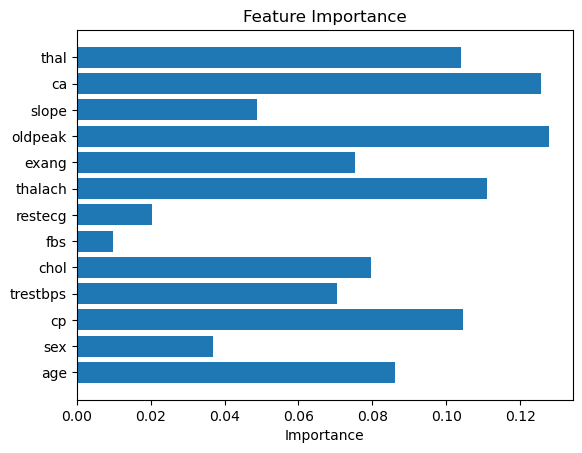

In [9]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.figure()
plt.barh(X.columns, importances)

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.show()

In [10]:
#comparing with decision tree

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree Accuracy: 0.7540983606557377
Random Forest Accuracy: 0.8524590163934426


## comparison with other model

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [12]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (SVC)": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

In [13]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name}: {acc:.4f}")

Random Forest: 0.8361
Gradient Boosting: 0.7705
SVM (SVC): 0.7049
Logistic Regression: 0.8852


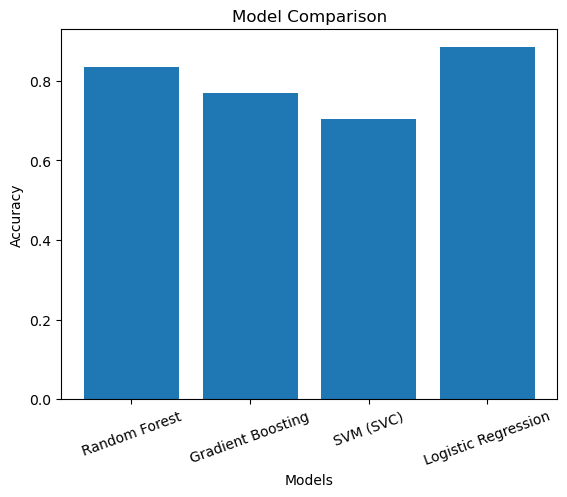

In [14]:
import matplotlib.pyplot as plt

names = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(names, scores)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=20)
plt.show()

## hyperparameter tuning of random forest 

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred))

Tuned RF Accuracy: 0.8688524590163934


> GridSearchCV

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [17]:
## choosing the best result
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

print("Best RF Accuracy:", accuracy_score(y_test, y_pred))

Best RF Accuracy: 0.8852459016393442


In [18]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

print(results[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head())

                                               params  mean_test_score
16  {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.814031
17  {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.814031
15  {'max_depth': 5, 'max_features': 'sqrt', 'min_...         0.814031
42  {'max_depth': 5, 'max_features': 'log2', 'min_...         0.814031
44  {'max_depth': 5, 'max_features': 'log2', 'min_...         0.814031


> ## RandomizedSearchCV (Recommended)

- Faster and more practical for real projects

In [19]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 8, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=10,   # try 10 random combinations
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}


In [23]:
## choosing the best result
best_randomf = random_search.best_estimator_

y_pred = best_randomf.predict(X_test)

print("Best RandomizedSearchCV  model Accuracy:", accuracy_score(y_test, y_pred))

Best RandomizedSearchCV  model Accuracy: 0.8524590163934426


## tuning strategy


1. Start with default model  
2. Tune n_estimators (100 → 300)  
3. Tune max_depth (control overfitting)  
4. Tune min_samples_* (stability)  
5. Tune max_features (randomness)  